# Recurrent Neural Networks

In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [9]:
sp500 = pd.read_csv('https://raw.githubusercontent.com/GettysburgDataScience/datasets/refs/heads/main/sp500_1950_2025_weekly.csv',
                    thousands = ',',
                    parse_dates = ['Date'])
sp500.head()

,Date,Price,Open,High,Low,Vol.,Change %
0,2025-08-31,6437.47,6386.45,6445.17,6360.53,NaN,-0.35%
1,2025-08-24,6460.26,6457.67,6508.23,6429.21,NaN,-0.10%
2,2025-08-17,6466.91,6445.02,6478.89,6343.86,NaN,0.27%
3,2025-08-10,6449.80,6389.67,6481.34,6364.06,NaN,0.94%
4,2025-08-03,6389.45,6271.71,6395.16,6271.71,NaN,2.43%


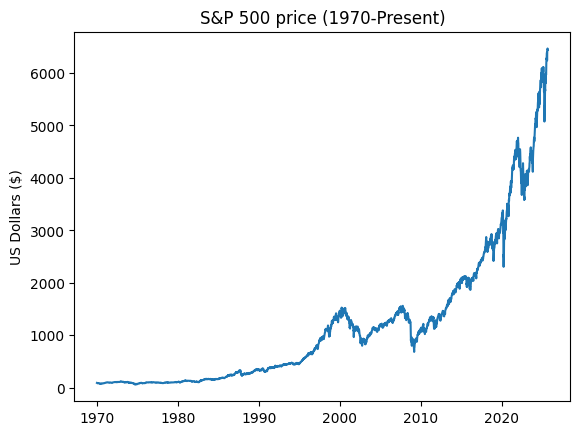

In [10]:
plt.plot(sp500['Date'], sp500['Price'])
plt.ylabel('US Dollars ($)')
plt.title('S&P 500 price (1970-Present)')
plt.show()

In [11]:
from keras.models import Sequential
from keras.layers import Dropout, Dense, SimpleRNN, LSTM, GRU, TimeDistributed
from keras.utils import timeseries_dataset_from_array

from sklearn.preprocessing import MinMaxScaler

In [17]:
cutoff = 1990
X_train = sp500.query('Date < @cutoff')[['Price']]
X_test = sp500.query('Date >= @cutoff')[['Price']]

mm = MinMaxScaler(feature_range = (0, 10000))

Xs_train = mm.fit_transform(X_train)
Xs_test = mm.transform(X_test)

Xs_train

array([[9777.40303541],
       [9817.87521079],
       [9615.5143339 ],
       ...,
       [ 903.87858347],
       [ 964.58684654],
       [1015.17706577]], shape=(1044, 1))

In [20]:
Xs = timeseries_dataset_from_array(data = Xs_train, targets = Xs_test,
                              sequence_length = 10, 
                              sequence_stride = 5)

for batch in Xs:
    x, y = batch

print(f'{x}\n{y}')

[[[1153.45699831]
  [1102.86677909]
  [1153.45699831]
  [1150.08431703]
  [1183.81112985]
  [1139.96627319]
  [1187.18381113]
  [1200.67453626]
  [1231.02866779]
  [1231.02866779]]

 [[1139.96627319]
  [1187.18381113]
  [1200.67453626]
  [1231.02866779]
  [1231.02866779]
  [1328.83642496]
  [1278.24620573]
  [1264.75548061]
  [1274.87352445]
  [1311.97301855]]

 [[1328.83642496]
  [1278.24620573]
  [1264.75548061]
  [1274.87352445]
  [1311.97301855]
  [1271.50084317]
  [1220.91062395]
  [1193.92917369]
  [1146.71163575]
  [1251.26475548]]

 [[1271.50084317]
  [1220.91062395]
  [1193.92917369]
  [1146.71163575]
  [1251.26475548]
  [1237.77403035]
  [1254.63743676]
  [1217.53794266]
  [1217.53794266]
  [1305.22765599]]

 [[1237.77403035]
  [1254.63743676]
  [1217.53794266]
  [1217.53794266]
  [1305.22765599]
  [1214.16526138]
  [1244.51939292]
  [1241.14671164]
  [1335.58178752]
  [1295.10961214]]

 [[1214.16526138]
  [1244.51939292]
  [1241.14671164]
  [1335.58178752]
  [1295.10961214]


2025-11-19 15:00:09.263533: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


In [ ]:
rnn = Sequential([
    SimpleRNN(20, return_sequences = True, input_shape = [None, 1]),
    Dropout(0.2),
    SimpleRNN(20, return_sequences = True),
    Dropout(0.2),
    TimeDistributed(Dense(10, activation = 'linear'))
    ]
)

rnn.compile(loss = 'MeanSquaredError', metrics=['MAE'], optimizer='Adam')
rnn.fit(Xs)

/Users/eatai/.pyenv/versions/datascience/lib/python3.13/site-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


ValueError: When providing `x` as a tf.data.Dataset, `y` should not be passed. Instead, the targets should be included as part of the tf.data.Dataset.